# Division verification
 This script addresses the reviewer's comment (R1, 3) by performing
 a repeated random train-test split to provide multi - dimensional evidence
 for the subsequent structure - property correlation analysis.

### import section

In [3]:
import math
import re
import time
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from sklearn.model_selection import ShuffleSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    root_mean_squared_error,
)
from typing import Dict
from joblib import load
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
!pwd

/home/sat/HL-gaps-pub/notebooks


/home/sat/anaconda3/envs/py312scikitlearn/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=21460) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


### loading and preprocessing

In [5]:
print("--- Loading and Preprocessing Data ---")
try:
    # Load descriptors
    X = pd.read_pickle("../data/processed/calc_descriptors_final.pkl")
    # Load target property (HL-Gap)
    df = pd.read_pickle("../data/processed/gap_smile.pkl")
    y = df["GAP"].to_numpy()
    print("Data loaded successfully.")
except FileNotFoundError as e:
    print(f"Error: {e}. Make sure the data files are in the correct path.")
    exit()

--- Loading and Preprocessing Data ---
Data loaded successfully.


### metrics

In [6]:
# --- Metrics ---
def get_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """Calculates regression metrics."""
    metrics = {
        "R2": r2_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
    }
    return metrics

### setup splitting

In [7]:
# Setup for 10 random splits (as requested by the reviewer)
n_splits = 5
test_size = 0.3
ss = ShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=42)

### evaluation

In [8]:
features_to_check = ['NumAromaticCarbocycles', 'SMR_VSA7', 'SMR_VSA10', 'HallKierAlpha']

all_splits_data = []
print("Processing splits to create a unified DataFrame for plotting...")
for i, (train_index, test_index) in enumerate(ss.split(X)):
    # Create train subset for this split
    train_df = X.iloc[train_index][features_to_check].copy()
    train_df['Split'] = i + 1
    train_df['Set'] = 'Train'
    
    # Create test subset for this split
    test_df = X.iloc[test_index][features_to_check].copy()
    test_df['Split'] = i + 1
    test_df['Set'] = 'Test'
    
    # Append to our list
    all_splits_data.extend([train_df, test_df])

# Combine all split data into a single DataFrame
plotting_df = pd.concat(all_splits_data, ignore_index=True)

# 'Melt' the DataFrame from a wide to a long format suitable for FacetGrid
melted_df = plotting_df.melt(
    id_vars=['Split', 'Set'], 
    value_vars=features_to_check, 
    var_name='Feature', 
    value_name='Value'
)
print("DataFrame prepared.")



Processing splits to create a unified DataFrame for plotting...
DataFrame prepared.


In [9]:
melted_df

,Split,Set,Feature,Value
0,1,Train,NumAromaticCarbocycles,0.00
1,1,Train,NumAromaticCarbocycles,1.00
2,1,Train,NumAromaticCarbocycles,2.00
3,1,Train,NumAromaticCarbocycles,1.00
4,1,Train,NumAromaticCarbocycles,2.00
...,...,...,...,...
8124055,5,Test,HallKierAlpha,-2.67
8124056,5,Test,HallKierAlpha,-3.18
8124057,5,Test,HallKierAlpha,-1.91
8124058,5,Test,HallKierAlpha,-2.36


### aggregate and report results

Generating plot...


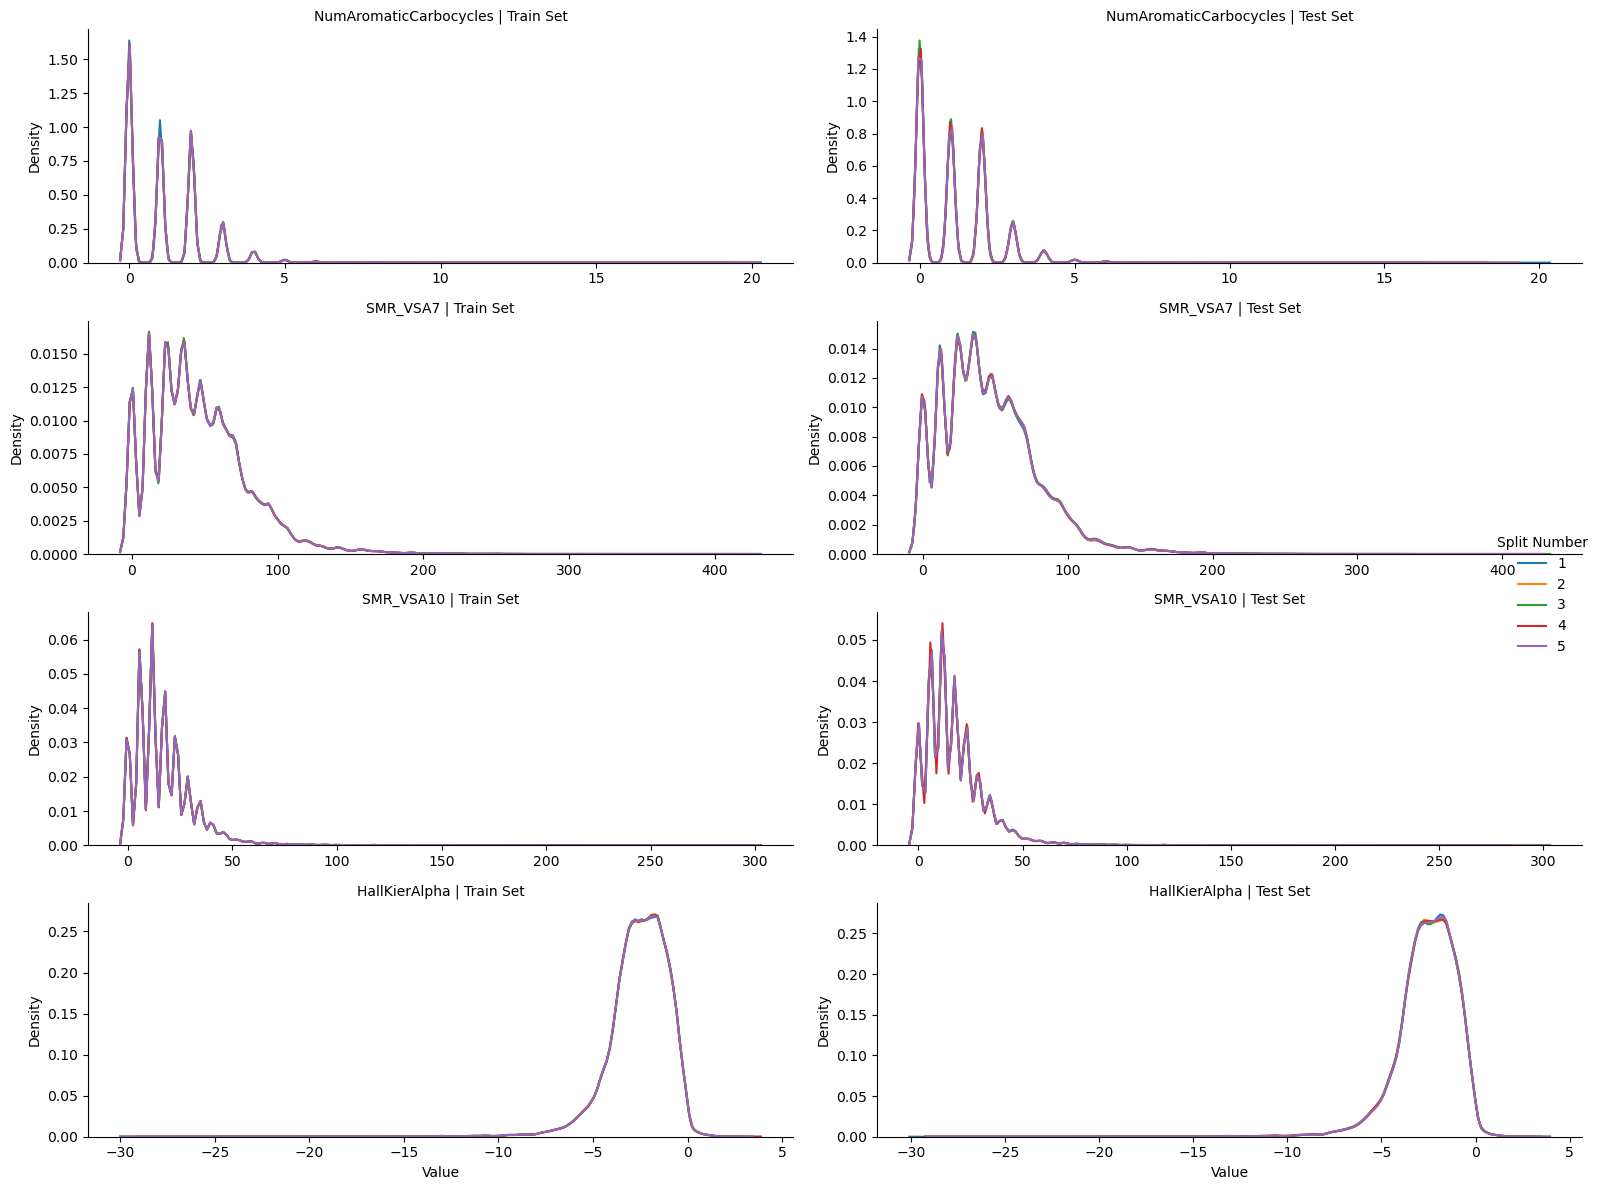

In [10]:
print("Generating plot...")

# Set up the FacetGrid: rows are Train/Test, columns are the Features
g = sns.FacetGrid(
    melted_df, 
    row='Feature', 
    col='Set', 
    hue='Split', # Splits are now distinguished by color within each plot
    height=3, 
    aspect=2.5,
    sharex=False, # Allow each plot to have its own x-axis range
    sharey=False  # Allow each plot to have its own y-axis range
)

# Map the KDE plot onto the grid (without fill)
g.map(sns.kdeplot, 'Value')

# Add a legend to identify the splits
g.add_legend(title='Split Number')

# Set informative titles for rows and columns
g.set_titles(row_template='{row_name}', col_template='{col_name} Set')

# Adjust spacing and display the plot
plt.tight_layout()
plt.show()

In [14]:
g.savefig('division_verification.png')